In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import time

In [2]:
epochs = 50
noise_dim = 100
batch_size = 32
latent_dim = 10

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Input images with a single channel
x_train, x_test = np.expand_dims(x_train, axis=-1), np.expand_dims(x_test, axis=-1)

# Normalize images value from [0, 255] to [-1, 1].
x_train, x_test = (x_train - 127.5) / 127.5, (x_test - 127.5) / 127.5

# Use tf.data API to shuffle and batch data.
buffer_size = x_train.shape[0]
train_data=tf.data.Dataset.from_tensor_slices(x_train)
train_data=train_data.shuffle(buffer_size).batch(batch_size).prefetch(1)

In [4]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(noise_dim + latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, 
                                     activation='tanh'))
    
    # takes noise of shape (noise_dim, ) and label of shape (latent_dim,) as inputs
    noise = layers.Input(shape=(noise_dim,))
    label = layers.Input(shape=(1,))
    label_embedded = layers.Flatten()(
        tf.cast(tf.one_hot(tf.cast(label, tf.int32), latent_dim), dtype=label.dtype))
    #label_embedded = layers.Flatten()(layers.Embedding(latent_dim, latent_dim)(label))

    #model_input = layers.concatenate([noise, latent])
    #model_input = layers.add([noise, label_embedded])
    #model_input = layers.multiply([noise, label_embedded])
    model_input = layers.concatenate([noise, label_embedded])
    
    img = model(model_input)

    return tf.keras.Model([noise, label], img)

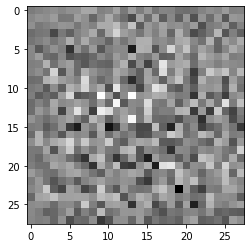

In [5]:
generator = make_generator_model()

noise = tf.random.normal([1, noise_dim])
#label = tf.random.uniform([1, latent_dim])
#label = label / tf.reduce_sum(label, axis=1)
label = tf.constant([[1]])

generated_image = generator([noise, label], training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [6]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    
    input_img = layers.Input(shape=(28, 28, 1))
    
    feature_vector = model(input_img)
    
    decision = layers.Dense(1)(feature_vector)
    
    return tf.keras.Model(input_img, [decision, feature_vector])

In [7]:
discriminator = make_discriminator_model()
decision, feature_vector = discriminator(generated_image, training=False)
print(feature_vector.shape)
print (decision)

(1, 6272)
tf.Tensor([[0.0018196]], shape=(1, 1), dtype=float32)


In [8]:
def make_proposal_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(latent_dim, input_shape=(6272,)))
    return model

In [9]:
proposal = make_proposal_model()

class_pred = proposal(feature_vector)
print (class_pred)

tf.Tensor(
[[ 0.00228673 -0.00081997 -0.0002096   0.000799    0.00057463 -0.00049007
   0.00065352  0.00142937  0.00139941  0.00149277]], shape=(1, 10), dtype=float32)


In [10]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# This method returns a helper function to compute cross entropy loss
class_cross_entropy = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [11]:
def mutual_info_loss(c, c_given_x):
    """The mutual information metric we aim to minimize"""
    # eps = 1e-8
    # K.mean(- K.sum(K.log(c_given_x + eps) * c, axis=1))
    conditional_entropy = class_cross_entropy(c, c_given_x) 
    
    #entropy = K.mean(- K.sum(K.log(c + eps) * c, axis=1))
    #entropy = class_cross_entropy(c, c)

    return conditional_entropy #+ entropy

In [12]:
def discriminator_loss(real_output, fake_output):
    # discriminator loss: recognize real to real and fake to fake
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [13]:
def generator_loss(fake_output):
    # generator loss: recognize fake to real
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(1e-3)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4)
proposal_optimizer = tf.keras.optimizers.Adam(2e-4)

# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.uniform(minval=-1., maxval=1., 
                              shape=(images.shape[0], noise_dim), dtype=tf.float32)
    random_labels = tf.random.uniform(minval=0, maxval=10, 
                              shape=(images.shape[0], ), dtype=tf.int32)
    
    with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:
        # fake image and fake class
        generated_images = generator([noise, random_labels], training=True)
        fake_output, _ = discriminator(generated_images, training=True)
        
        # real image
        real_output, _ = discriminator(images, training=True)
        
        # loss
        disc_loss = discriminator_loss(real_output, fake_output)
        gen_loss = generator_loss(fake_output)
    
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)

    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    
    with tf.GradientTape() as prop_tape:
        generated_images = generator([noise, random_labels], training=True)
        _, fake_feature = discriminator(generated_images, training=True)
        fake_class_pred = proposal(fake_feature, training=True)
        prop_loss = mutual_info_loss(random_labels, fake_class_pred)
    
    gradients_of_proposal = prop_tape.gradient(prop_loss, # proposal.trainable_variables)
                                generator.trainable_variables + proposal.trainable_variables 
                                               + discriminator.trainable_variables)
    proposal_optimizer.apply_gradients(zip(gradients_of_proposal, # proposal.trainable_variables))
                                generator.trainable_variables + proposal.trainable_variables 
                                               + discriminator.trainable_variables))

In [15]:
def generate_and_save_images(model, epoch, test_input, test_label):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model([test_input, test_label], training=False)

    fig = plt.figure(figsize=(10, 3))

    for i in range(predictions.shape[0]):
        plt.subplot(3, 10, i+1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

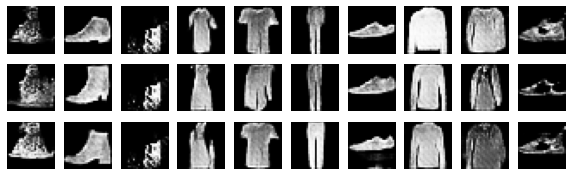

In [16]:
from IPython import display

seed_noise = tf.random.uniform(minval=-1, maxval=1, shape=[30, noise_dim], dtype=tf.float32)
seed_label = tf.constant(range(10))
seed_label = tf.concat([seed_label, seed_label, seed_label], axis=0)

for epoch in range(epochs):
    start = time.time()

    for image_batch in train_data:
        train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed_noise, seed_label)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

# Generate after the final epoch
display.clear_output(wait=True)
generate_and_save_images(generator,
                       epochs,
                       seed_noise, seed_label)

In [17]:
import glob
import imageio

anim_file = 'gan-infogan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('image_at_epoch_*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
    image = imageio.imread(filename)
    writer.append_data(image)

![](./gan-infogan.gif)